In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


In [ ]:
uploaded = files.upload()

Saving Picture1.jpg to Picture1.jpg
Saving Picture2.png to Picture2.png
Saving Picture3.png to Picture3.png
Saving Picture4.jpg to Picture4.jpg
Saving Picture5.jpg to Picture5.jpg


In [ ]:
def show_image(img, title="Image", cmap=None):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

**1. Brighten the image**

**Read image**

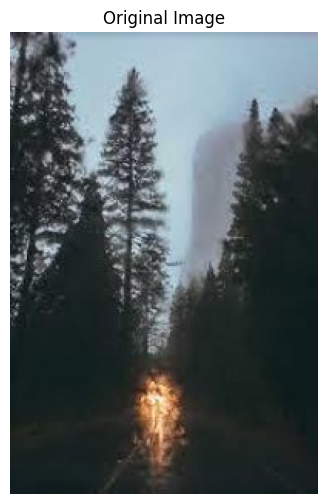

In [ ]:
img_bright = cv2.imread("Picture1.jpg")
img_bright = cv2.cvtColor(img_bright, cv2.COLOR_BGR2RGB)

show_image(img_bright, "Original Image")

**Brighten image**

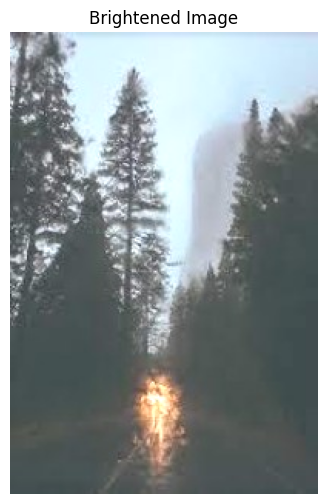

In [ ]:
brightness_value = 50

brightened_img = cv2.add(img_bright, np.ones(img_bright.shape, dtype=np.uint8) * brightness_value)

show_image(brightened_img, "Brightened Image")

**2. Find digital negative**

**Read image**

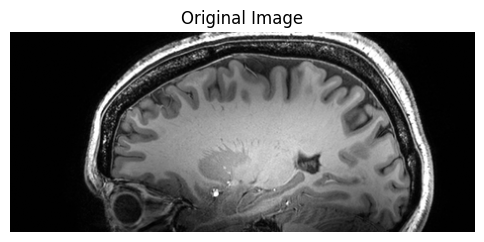

In [ ]:
img_negative = cv2.imread("negative.jpeg", cv2.IMREAD_GRAYSCALE)

show_image(img_negative, "Original Image", cmap="gray")

**Digital negative**

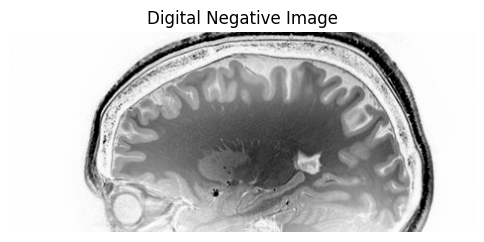

In [ ]:
negative_img = 255 - img_negative

show_image(negative_img, "Digital Negative Image", cmap="gray")

**3. Adjust contrast**

**Read image**

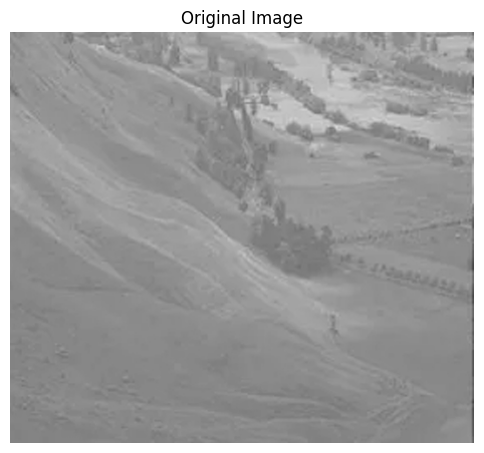

In [ ]:
img_contrast = cv2.imread("contrast.jpeg")
img_contrast = cv2.cvtColor(img_contrast, cv2.COLOR_BGR2RGB)

show_image(img_contrast, "Original Image")

**Adjust contrast**

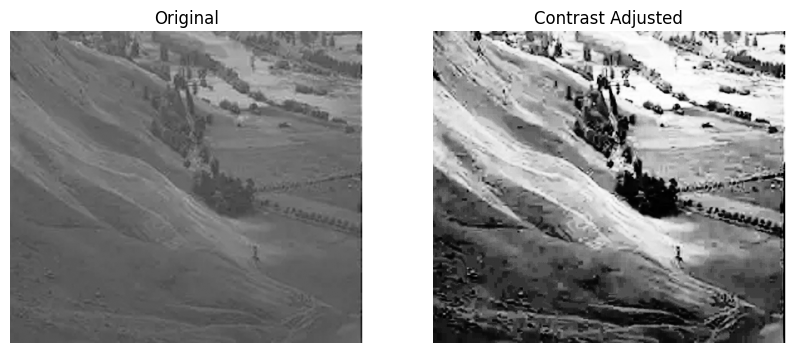

In [ ]:
img = cv2.imread("contrast.jpeg", cv2.IMREAD_GRAYSCALE)

equalized = cv2.equalizeHist(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(equalized, cmap='gray')
plt.title("Contrast Adjusted")
plt.axis('off')

plt.show()

**4. Contrast stretching**

**Read grayscale image**

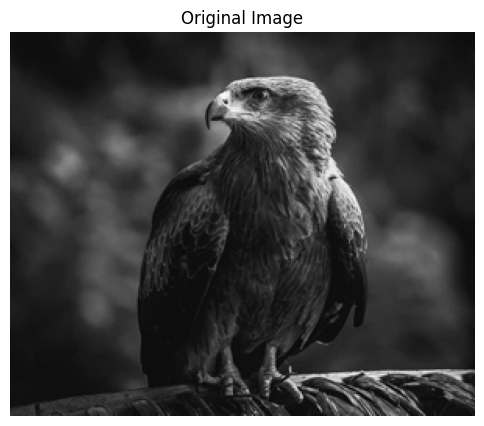

In [ ]:
img_stretch = cv2.imread("stretch.jpeg", cv2.IMREAD_GRAYSCALE)

show_image(img_stretch, "Original Image", cmap="gray")

**Apply contrast stretching**

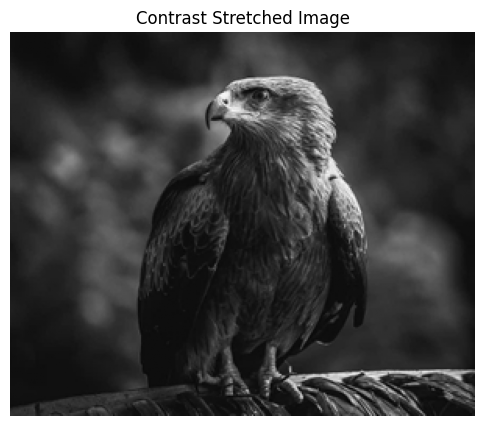

In [ ]:
min_pixel = np.min(img_stretch)
max_pixel = np.max(img_stretch)

contrast_stretched = ((img_stretch - min_pixel) / (max_pixel - min_pixel)) * 255
contrast_stretched = contrast_stretched.astype(np.uint8)

show_image(contrast_stretched, "Contrast Stretched Image", cmap="gray")

**5. Bit-plane slicing**

**Read image**

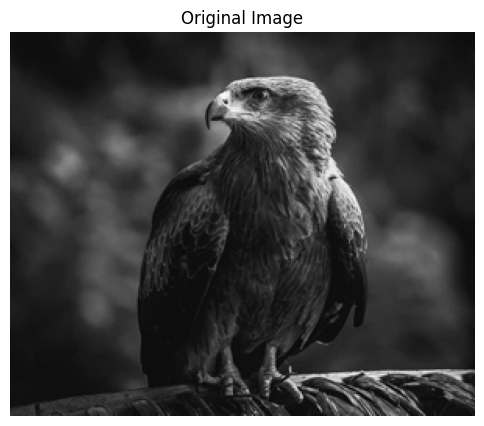

In [ ]:
img_bitplane = cv2.imread("bitplane.jpeg", cv2.IMREAD_GRAYSCALE)

show_image(img_bitplane, "Original Image", cmap="gray")

**Apply bit-plane slicing**

In [ ]:
bit_planes = []

for i in range(8):
    bit_plane = cv2.bitwise_and(img_bitplane, 2**i)
    bit_plane = np.where(bit_plane > 0, 255, 0).astype(np.uint8)
    bit_planes.append(bit_plane)

**Show all 8 bit planes**

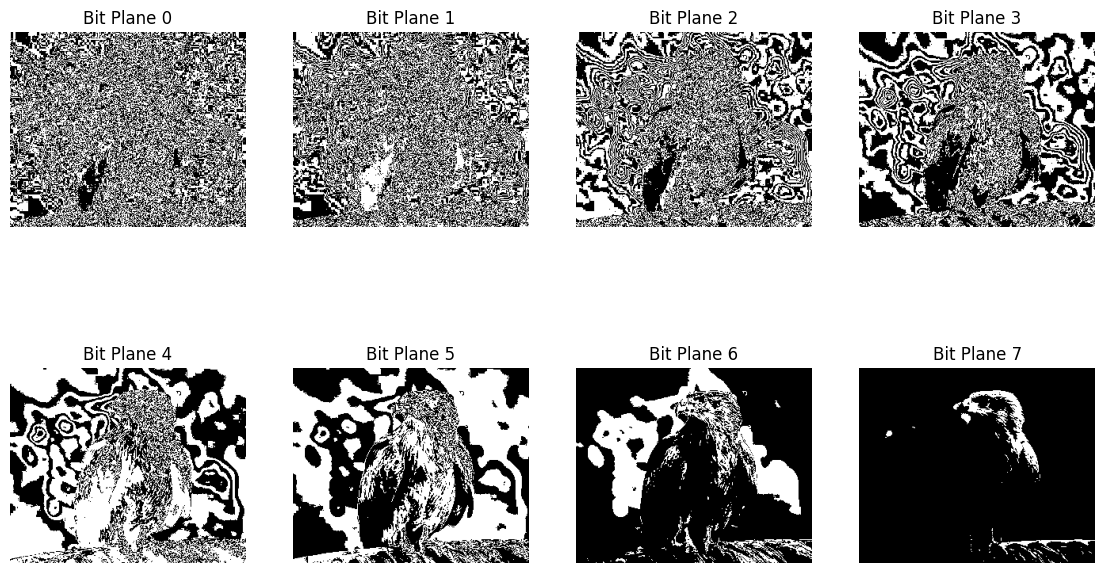

In [ ]:
plt.figure(figsize=(14,8))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(bit_planes[i], cmap="gray")
    plt.title(f"Bit Plane {i}")
    plt.axis("off")

plt.show()

**Show most important bit planes**

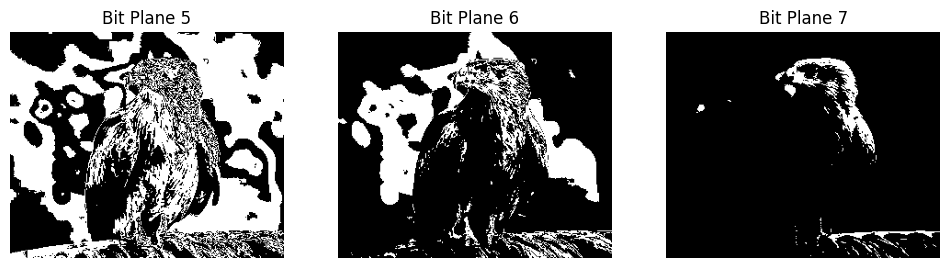

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(bit_planes[5], cmap="gray")
plt.title("Bit Plane 5")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(bit_planes[6], cmap="gray")
plt.title("Bit Plane 6")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(bit_planes[7], cmap="gray")
plt.title("Bit Plane 7")
plt.axis("off")

plt.show()